In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

from standard_results import final_size_success_mean, final_size_success_sd, probability_failure, failed_dist, final_size_failed_mn

def float_to_str(x, precision=6):
    s = f"{x:.{precision}f}".rstrip('0').rstrip('.')
    return s.replace('.', 'p')

def params_to_filename(params):
    parts = []
    for key in params:
        val = params[key]
        if isinstance(val, float):
            val = float_to_str(val)
        parts.append(f"{key}_{val}")
    return "__".join(parts)

In [18]:
def read_data(R0, trec, N, epsilons):
    epi_params = {"R0": R0, "trec": trec, "N": N}

    # Targets
    mn_fail = final_size_failed_mn(R0)
    mn_norm = final_size_success_mean(R0)
    mn = mn_norm * N
    sd = final_size_success_sd(N, R0)
    p_fail = probability_failure(R0)

    targets = {"mn_fail": mn_fail, "mn_norm": mn_norm, "mn": mn, "sd": sd, "p": p_fail}

    # Data
    dfs = []

    # epsilon leap
    for epsilon in epsilons:
        parameters = {"epsilon": epsilon}
        fname = params_to_filename( parameters | epi_params )
        dfs.append(pd.read_csv(f"out/tau_adaptive__{fname}.csv"))

    return {"R0": R0, "epsilons": epsilons, "dfs": dfs, "targets": targets}

trec=4.0
N=100000

df1 = read_data(1.2, 4.0, 100000, [0.01, 0.03, 0.1, 0.3, 1])
df2 = read_data(2.0, 4.0, 100000, [0.01, 0.03, 0.1, 0.3, 1])

outs = [df1, df2]

Compare errors

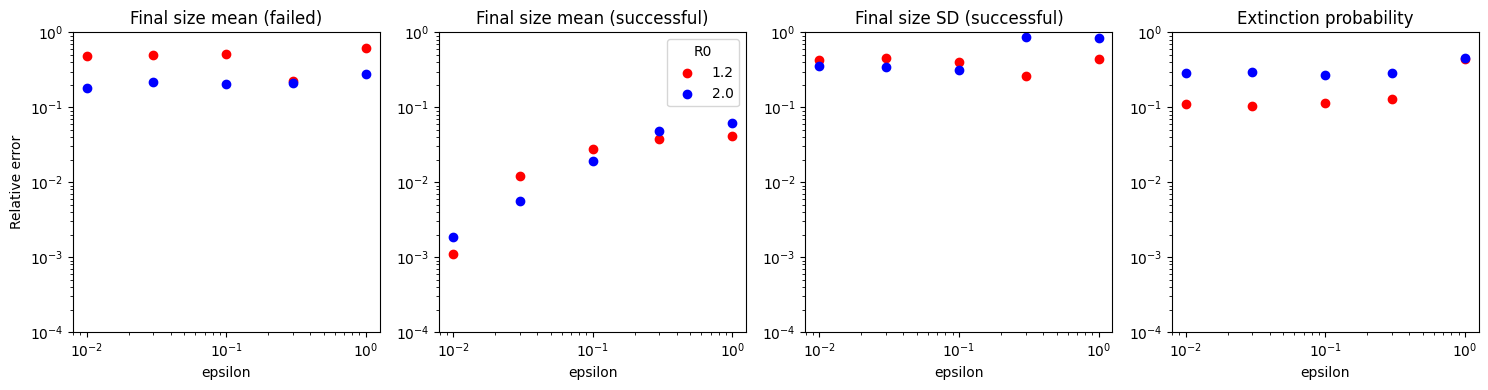

In [19]:
fig, ax = plt.subplots(1, 4, figsize = (15,4))

colors = ["red", "blue"]

for j, out in enumerate(outs):
    mn_fail = out['targets']['mn_fail']
    mn_norm = out['targets']['mn_norm']
    mn = out['targets']['mn']
    sd = out['targets']['sd']
    p_fail = out['targets']['p']

    dfs = out["dfs"]
    epsilons = out["epsilons"]

    cutoff = 0.5 * mn

    R0 = out["R0"]

    axis= ax[0]

    errs = []
    for i, df in enumerate(dfs):
        y = df['final_size']

        y = y[y<cutoff]
        mn_obs = y.mean()

        err = abs(mn_obs - mn_fail) / mn_fail
        errs.append(err)
    axis.scatter(epsilons, errs, color=colors[j], label=R0)
    axis.set_xscale("log")
    axis.set_yscale("log")
    axis.set_title("Final size mean (failed)")

    axis= ax[1]
    errs = []
    for i, df in enumerate(dfs):
        y = df['final_size']

        y = y[y>cutoff] / N

        mn_obs = y.mean()

        err = abs(mn_obs - mn_norm)/mn_norm
        errs.append(err)

    axis.scatter(epsilons, errs, color=colors[j], label=R0)
    axis.set_xscale("log")
    axis.set_yscale("log")
    axis.set_title("Final size mean (successful)")

    axis = ax[2]
    errs = []
    for i, df in enumerate(dfs):
        y = df['final_size']

        y = y[y>cutoff]

        sd_obs = y.std()

        err = abs(sd_obs - sd)/sd
        errs.append(err)

    axis.scatter(epsilons, errs, color=colors[j], label=R0)
    axis.set_yscale("log")
    axis.set_xscale("log")
    axis.set_title("Final size SD (successful)")

    axis = ax[3]
    errs = []
    for i, df in enumerate(dfs):
        y = df['final_size']

        n_sim = len(y)
        n_fail = len(y[y<cutoff])

        p_fail_obs = n_fail / n_sim

        err = abs(p_fail_obs - p_fail) / p_fail
        errs.append(err)

    axis.scatter(epsilons, errs, color=colors[j], label=R0)
    axis.set_yscale("log")
    axis.set_xscale("log")
    axis.set_title("Extinction probability")

    for axis in ax:
        axis.set_ylim(1e-4, 1e-0)
        axis.set_xlabel("epsilon")

ax[1].legend(title="R0")
ax[0].set_ylabel("Relative error")
plt.tight_layout()
plt.show()

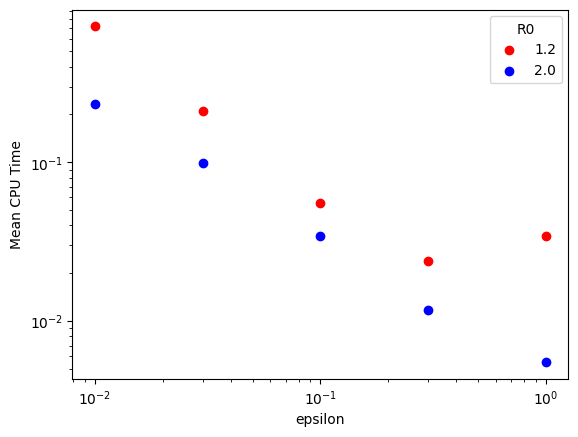

In [20]:
for j, out in enumerate(outs):
    times = []
    sizes = []
    p_fails = []

    mn_fail = out['targets']['mn_fail']
    mn_norm = out['targets']['mn_norm']
    mn = out['targets']['mn']
    sd = out['targets']['sd']
    p_fail = out['targets']['p']

    dfs = out["dfs"]
    epsilons = out["epsilons"]

    cutoff = 0.5 * mn

    R0 = out["R0"]

    for i, df in enumerate(dfs):
        filtered = df[df['final_size'] > cutoff]
        times.append(filtered['cpu_time_seconds'].mean())
    plt.scatter(epsilons, times, label = R0, color=colors[j])
plt.legend(title="R0")
plt.xscale("log")
plt.yscale("log")
plt.xlabel("epsilon")
plt.ylabel("Mean CPU Time")
plt.show()

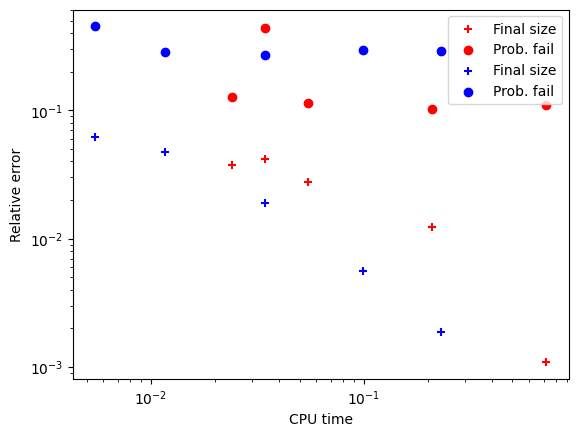

In [21]:
for j, out in enumerate(outs):
    times = []
    sizes = []
    p_fails = []

    mn_fail = out['targets']['mn_fail']
    mn_norm = out['targets']['mn_norm']
    mn = out['targets']['mn']
    sd = out['targets']['sd']
    p_fail = out['targets']['p']

    dfs = out["dfs"]
    epsilons = out["epsilons"]

    cutoff = 0.5 * mn

    R0 = out["R0"]

    for i, df in enumerate(dfs):
        filtered = df[df['final_size'] > cutoff]
        times.append(filtered['cpu_time_seconds'].mean())

        y = df['final_size']
        y = y[y>cutoff] / N
        mn_obs = y.mean()
        err = abs(mn_obs - mn_norm)/mn_norm
        sizes.append(err)

        y = df['final_size']

        n_sim = len(y)
        n_fail = len(y[y<cutoff])

        p_fail_obs = n_fail / n_sim

        p_fails.append(abs(p_fail_obs - p_fail) / p_fail)

    plt.scatter(times, sizes, label = "Final size", color=colors[j], marker = "+")
    plt.scatter(times, p_fails, label = "Prob. fail", color=colors[j])
plt.xscale("log")
plt.yscale("log")
plt.xlabel("CPU time")
plt.ylabel("Relative error")
plt.legend()
plt.show()
